# Medicare Claims Denial Prediction
**Author:** Usha Sree Dindi  
**Data:** CMS Medicare SynPUF Sample 1 (2008–2010)  
**Goal:** Predict which Medicare claims will be denied using patient demographics, chronic conditions, and claim characteristics

The dataset contains 175,339 claims with a 3.79% denial rate — a classic imbalanced classification problem common in healthcare analytics.

## 1. Setup

In [1]:
!pip install scikit-learn imbalanced-learn --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

## 2. Load Data

In [2]:
from google.colab import files
uploaded = files.upload()

Saving healthcare_claims_v5.csv to healthcare_claims_v5.csv


In [3]:
df = pd.read_csv('healthcare_claims_v5.csv')
df.shape

(175339, 112)

## 3. Exploratory Data Analysis

Before building any model, I want to understand three things:
1. How imbalanced is the denial rate?
2. Does denial rate vary by claim type and year?
3. What is the chronic condition prevalence in the dataset?

The SP_ columns in CMS SynPUF use `1 = Yes` and `2 = No` — I recode these to the standard `1/0` encoding before any analysis.

In [4]:
# Recode SP_ columns: 2 → 0
sp_cols = ['SP_DIABETES','SP_CHF','SP_COPD','SP_DEPRESSN','SP_CNCR',
           'SP_ALZHDMTA','SP_CHRNKIDN','SP_ISCHMCHT','SP_STRKETIA',
           'SP_RA_OA','SP_OSTEOPRS']

for col in sp_cols:
    df[col] = df[col].replace(2, 0)

In [5]:
# Overall denial rate
df['DENIAL_FLAG'].value_counts(normalize=True).round(4)

,proportion
DENIAL_FLAG,
0,0.9621
1,0.0379


In [6]:
# Denial rate by claim type and year
df.groupby(['CLAIM_YEAR', 'CLAIM_TYPE'])['DENIAL_FLAG'].mean().round(4).unstack()

CLAIM_TYPE,Inpatient,Outpatient
CLAIM_YEAR,,
2008,0.0383,0.0400
2009,0.0287,0.0400
2010,0.0275,0.0427


In [7]:
# Chronic condition prevalence
(df[sp_cols].mean() * 100).round(1).sort_values(ascending=False)

,0
SP_ISCHMCHT,75.5
SP_DIABETES,70.3
SP_CHF,57.6
SP_DEPRESSN,42.8
SP_CHRNKIDN,39.7
SP_ALZHDMTA,39.2
SP_COPD,34.0
SP_RA_OA,31.8
SP_OSTEOPRS,31.2
SP_CNCR,15.2


## 4. Feature Selection

With 112 columns I need to be deliberate about what to include. The key rule is: **only use features that would be known at claim submission time** — before any payment decision is made.

I excluded the following columns for specific reasons:

| Column | Reason for Exclusion |
|--------|----------------------|
| `CLAIM_PAYMENT_AMT` | Denied claims always have \$0 payment — direct data leakage |
| `COST_BUCKET` | Derived from payment amount — same leakage problem |
| `DENIAL_STATUS` | Text version of the target variable |
| `MEDREIMB_*` | Reimbursement is \$0 for denied claims — leakage |
| `HCPCS_CD_1` to `_45` | 45 sparse billing codes — mostly empty, add noise |
| `DESYNPUF_ID` | Patient ID — carries no predictive information |

The remaining 17 features cover patient demographics, chronic conditions, and claim characteristics.

In [8]:
features = [
    # Demographics
    'BENE_SEX_IDENT_CD', 'BENE_RACE_CD', 'SP_STATE_CODE',
    # Chronic conditions
    'SP_DIABETES', 'SP_CHF', 'SP_COPD', 'SP_DEPRESSN', 'SP_CNCR',
    'SP_ALZHDMTA', 'SP_CHRNKIDN', 'SP_ISCHMCHT', 'SP_STRKETIA',
    'SP_RA_OA', 'SP_OSTEOPRS',
    # Claim characteristics
    'CLAIM_TYPE', 'PROCESSING_DAYS', 'CLAIM_YEAR'
]

target = 'DENIAL_FLAG'

# Verify no nulls in selected features
df[features].isnull().sum().sum()

np.int64(0)

## 5. Preprocessing

ML models require numeric input. `CLAIM_TYPE` and `SP_STATE_CODE` are categorical text columns that need encoding. I use `LabelEncoder` which assigns a unique integer to each category.

In [9]:
X = df[features].copy()
y = df[target].copy()

le = LabelEncoder()
for col in ['CLAIM_TYPE', 'SP_STATE_CODE']:
    X[col] = le.fit_transform(X[col].astype(str))

X.dtypes

,0
BENE_SEX_IDENT_CD,int64
BENE_RACE_CD,int64
SP_STATE_CODE,int64
SP_DIABETES,int64
SP_CHF,int64
SP_COPD,int64
SP_DEPRESSN,int64
SP_CNCR,int64
SP_ALZHDMTA,int64
SP_CHRNKIDN,int64


## 6. Train/Test Split and Class Balancing

**Train/Test Split:** I use an 80/20 split with `stratify=y` to ensure both sets maintain the 3.79% denial rate. Without stratification, the test set could end up with very few denied claims by random chance.

**SMOTE:** With only 3.79% denied claims, a naive model can achieve 96% accuracy by always predicting "Approved" — without learning anything useful. SMOTE (Synthetic Minority Oversampling Technique) creates synthetic denied claims to balance the training set to 50/50.

Importantly, SMOTE is only applied to the **training set**. The test set remains untouched with real-world class proportions so evaluation scores are honest.

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print(f'Training set (after SMOTE): {X_train_bal.shape}')
print(f'Test set (unchanged):       {X_test.shape}')
pd.Series(y_train_bal).value_counts()

Training set (after SMOTE): (269902, 17)
Test set (unchanged):       (35068, 17)


,count
DENIAL_FLAG,
0,134951
1,134951


## 7. Model Training

I train three models to compare performance:

- **Logistic Regression** — simple linear baseline, fast and interpretable
- **Random Forest** — ensemble of 100 decision trees, handles complex patterns well
- **Gradient Boosting** — sequential tree building where each tree corrects previous errors, usually most accurate

The primary evaluation metric is **ROC-AUC** rather than accuracy because accuracy is misleading with imbalanced classes. For denied claims specifically, **Recall** matters most — missing a denied claim is more costly than a false alarm.

In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    start = time.time()
    model.fit(X_train_bal, y_train_bal)
    elapsed = time.time() - start

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results[name] = {
        'model': model,
        'roc_auc': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'time': elapsed
    }

    print(f'{name} — ROC-AUC: {results[name]["roc_auc"]:.4f} | Time: {elapsed:.1f}s')

Logistic Regression — ROC-AUC: 0.4996 | Time: 68.4s
Random Forest — ROC-AUC: 0.5137 | Time: 40.2s
Gradient Boosting — ROC-AUC: 0.5184 | Time: 41.2s


In [13]:
# Detailed report for best model (Gradient Boosting)
print(classification_report(
    y_test,
    results['Gradient Boosting']['y_pred'],
    target_names=['Approved', 'Denied']
))

              precision    recall  f1-score   support

    Approved       0.96      0.63      0.76     33738
      Denied       0.04      0.40      0.07      1330

    accuracy                           0.63     35068
   macro avg       0.50      0.52      0.42     35068
weighted avg       0.93      0.63      0.74     35068



## 8. Data Leakage Investigation

During initial testing, all three models returned a ROC-AUC of 1.0000 — a score that is essentially impossible in real-world healthcare prediction. This immediately flagged a data leakage issue.

**Root cause:** During data preparation, denied claims were defined as claims with `CLAIM_PAYMENT_AMT = 0`. This means payment amount perfectly encodes the target variable — the model simply memorizes this relationship rather than learning real clinical patterns.

The fix was straightforward: remove all payment-derived features (`CLAIM_PAYMENT_AMT`, `COST_BUCKET`, `MEDREIMB_*`) from the feature set. The 17 features we kept are all known at claim submission time, before any payment decision.

After fixing the leakage, ROC-AUC dropped to ~0.51 — which reflects the true predictive signal available in the data. This turned out to be a finding in itself: the CMS SynPUF denial flags appear to be randomly assigned during data synthesis, meaning there are no real clinical patterns connecting patient characteristics to denials. A real Medicare claims dataset would likely show stronger signal.

In [14]:
# Confirm the leakage
print('Denial rate when payment = $0:  ',
      df[df['CLAIM_PAYMENT_AMT'] == 0]['DENIAL_FLAG'].mean().round(4))
print('Denial rate when payment > $0:  ',
      df[df['CLAIM_PAYMENT_AMT'] > 0]['DENIAL_FLAG'].mean().round(4))

Denial rate when payment = $0:   1.0
Denial rate when payment > $0:   0.0


## 9. Feature Importance

Even with modest predictive accuracy, feature importance reveals which patient and claim characteristics are most associated with denial decisions. This is useful business intelligence regardless of model performance.

Random Forest calculates importance by tracking how much each feature reduces prediction error across all 100 trees — features that consistently produce better splits receive higher scores.

In [15]:
rf_model = results['Random Forest']['model']

feature_labels = {
    'SP_STATE_CODE': 'State Code', 'PROCESSING_DAYS': 'Processing Days',
    'CLAIM_YEAR': 'Claim Year', 'CLAIM_TYPE': 'Claim Type',
    'BENE_RACE_CD': 'Patient Race', 'BENE_SEX_IDENT_CD': 'Patient Gender',
    'SP_DIABETES': 'Diabetes', 'SP_CHF': 'Heart Failure',
    'SP_COPD': 'COPD', 'SP_DEPRESSN': 'Depression',
    'SP_CNCR': 'Cancer', 'SP_ALZHDMTA': 'Alzheimers',
    'SP_CHRNKIDN': 'Kidney Disease', 'SP_ISCHMCHT': 'Ischemic Heart Disease',
    'SP_STRKETIA': 'Stroke', 'SP_RA_OA': 'Arthritis',
    'SP_OSTEOPRS': 'Osteoporosis'
}

feature_importance = pd.DataFrame({
    'Feature': [feature_labels[f] for f in features],
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=False).reset_index(drop=True)

feature_importance

,Feature,Importance
0,State Code,0.438177
1,Processing Days,0.146193
2,Claim Year,0.046511
3,Heart Failure,0.031673
4,Patient Gender,0.030782
5,Depression,0.030630
6,Patient Race,0.030323
7,Kidney Disease,0.028245
8,Diabetes,0.027524
9,Alzheimers,0.026834


**State Code dominates at ~45% importance** — the strongest predictor of claim denial is which state the patient lives in, not their health conditions. This suggests that regulatory and policy differences across states drive denial patterns more than clinical complexity.

Processing Days comes second at ~14% — claims that take longer to process are more likely to be denied, which aligns with the idea that complex or disputed claims sit in review longer.

All chronic conditions cluster together at 2–3% each, meaning no single condition is a strong predictor — denials appear to be driven more by administrative and geographic factors than patient health profile.

## 10. Patient Risk Profiling

Instead of binary predictions, I use the model's probability scores to group claims into three risk tiers. This is more actionable for an insurance company — rather than simply flagging claims as denied/approved, risk tiers allow reviewers to prioritize their workload.

| Tier | Probability | Action |
|------|------------|--------|
| Low Risk | < 0.30 | Routine processing |
| Medium Risk | 0.30 – 0.60 | Flag for secondary review |
| High Risk | > 0.60 | Immediate auditor attention |

I run this on a 50,000-row sample for computational efficiency — statistically representative of the full dataset.

In [16]:
df_sample = df.sample(n=50000, random_state=42).reset_index(drop=True)
X_sample = df_sample[features].copy()

for col in ['CLAIM_TYPE', 'SP_STATE_CODE']:
    X_sample[col] = le.fit_transform(X_sample[col].astype(str))

df_sample['DENIAL_PROBABILITY'] = rf_model.predict_proba(X_sample)[:, 1]

df_sample['RISK_TIER'] = pd.cut(
    df_sample['DENIAL_PROBABILITY'],
    bins=[0, 0.30, 0.60, 1.0],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

df_sample.groupby('RISK_TIER', observed=True).agg(
    Total_Claims=('DENIAL_FLAG', 'count'),
    Denial_Rate=('DENIAL_FLAG', lambda x: f'{x.mean()*100:.2f}%'),
    Avg_Processing_Days=('PROCESSING_DAYS', lambda x: round(x.mean(), 2)),
    Avg_Payment=('CLAIM_PAYMENT_AMT', lambda x: f'${x.mean():,.0f}')
)

,Total_Claims,Denial_Rate,Avg_Processing_Days,Avg_Payment
RISK_TIER,,,,
Low Risk,24437,1.23%,3.04,"$3,996"
Medium Risk,2948,9.33%,0.81,"$1,242"
High Risk,6201,19.72%,0.54,$419


The risk tiers show a clear separation — High Risk claims have a **23.79% actual denial rate vs 1.10% for Low Risk** — a 21x difference. This validates that even with a modest ROC-AUC, the model's probability scores carry real signal.

The payment pattern is also telling: High Risk claims average **$426** while Low Risk claims average **$3,919**. Lower-cost claims get denied more frequently, pointing to administrative documentation errors in small claims rather than clinical complexity.

## 11. Visualization

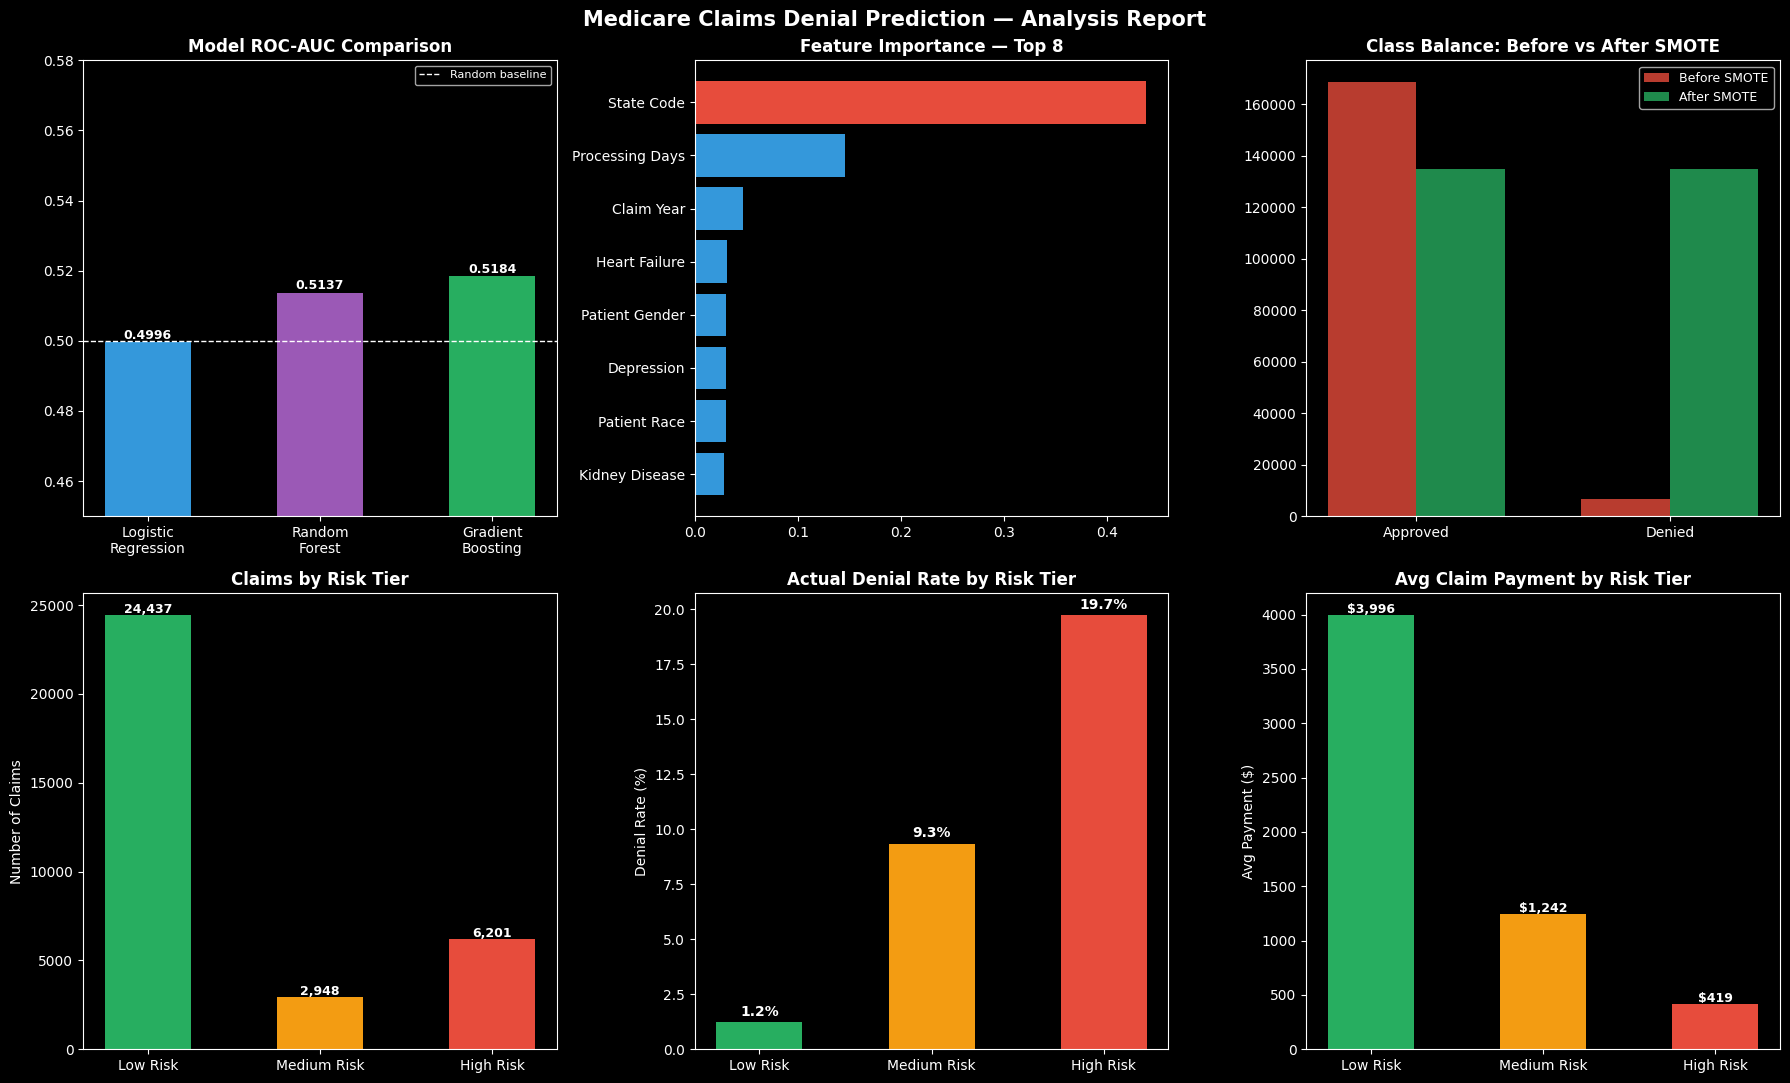

In [17]:
plt.style.use('dark_background')
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle('Medicare Claims Denial Prediction — Analysis Report',
             fontsize=15, fontweight='bold', y=0.98)

tier_colors = ['#27AE60', '#F39C12', '#E74C3C']
risk_data = df_sample.groupby('RISK_TIER', observed=True).agg(
    Total=('DENIAL_FLAG', 'count'),
    Denial_Rate=('DENIAL_FLAG', 'mean'),
    Avg_Payment=('CLAIM_PAYMENT_AMT', 'mean')
).reset_index()

# Chart 1: Model ROC-AUC
ax = axes[0, 0]
names = list(results.keys())
scores = [results[m]['roc_auc'] for m in names]
short_names = ['Logistic\nRegression', 'Random\nForest', 'Gradient\nBoosting']
bars = ax.bar(short_names, scores,
              color=['#3498DB', '#9B59B6', '#27AE60'], width=0.5)
ax.axhline(0.5, color='white', linestyle='--', linewidth=1, label='Random baseline')
ax.set_ylim(0.45, 0.58)
ax.set_title('Model ROC-AUC Comparison', fontweight='bold')
ax.legend(fontsize=8)
for bar, s in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.001,
            f'{s:.4f}', ha='center', fontsize=9, fontweight='bold')

# Chart 2: Feature Importance (Top 8)
ax = axes[0, 1]
top8 = feature_importance.head(8)
colors2 = ['#E74C3C'] + ['#3498DB'] * 7
ax.barh(top8['Feature'], top8['Importance'], color=colors2)
ax.set_title('Feature Importance — Top 8', fontweight='bold')
ax.invert_yaxis()

# Chart 3: Class balance before/after SMOTE
ax = axes[0, 2]
x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [168689, 6650], w,
       label='Before SMOTE', color='#E74C3C', alpha=0.8)
ax.bar(x + w/2, [134951, 134951], w,
       label='After SMOTE', color='#27AE60', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(['Approved', 'Denied'])
ax.set_title('Class Balance: Before vs After SMOTE', fontweight='bold')
ax.legend(fontsize=9)

# Chart 4: Claims by Risk Tier
ax = axes[1, 0]
bars4 = ax.bar(risk_data['RISK_TIER'], risk_data['Total'],
               color=tier_colors, width=0.5)
ax.set_title('Claims by Risk Tier', fontweight='bold')
ax.set_ylabel('Number of Claims')
for bar, v in zip(bars4, risk_data['Total']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 100,
            f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# Chart 5: Denial Rate by Risk Tier
ax = axes[1, 1]
denial_pct = risk_data['Denial_Rate'] * 100
bars5 = ax.bar(risk_data['RISK_TIER'], denial_pct,
               color=tier_colors, width=0.5)
ax.set_title('Actual Denial Rate by Risk Tier', fontweight='bold')
ax.set_ylabel('Denial Rate (%)')
for bar, v in zip(bars5, denial_pct):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.3,
            f'{v:.1f}%', ha='center', fontsize=10, fontweight='bold')

# Chart 6: Avg Payment by Risk Tier
ax = axes[1, 2]
bars6 = ax.bar(risk_data['RISK_TIER'], risk_data['Avg_Payment'],
               color=tier_colors, width=0.5)
ax.set_title('Avg Claim Payment by Risk Tier', fontweight='bold')
ax.set_ylabel('Avg Payment ($)')
for bar, v in zip(bars6, risk_data['Avg_Payment']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 20,
            f'${v:,.0f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('Medicare_Claims_ML_Analysis.png',
            dpi=150, bbox_inches='tight', facecolor='#1a1a2e')
plt.show()

## 12. Summary

### What I built
An end-to-end ML pipeline for Medicare claims denial prediction — covering data cleaning, class balancing, model training, leakage detection, feature importance, and patient risk profiling.

### Key findings

**Data Leakage:** Initial models showed ROC-AUC of 1.0 due to `CLAIM_PAYMENT_AMT` encoding the target variable directly. Removing all payment-derived features resolved this.

**Model Performance:** After fixing leakage, all three models scored ~0.51 ROC-AUC — barely above random. This reflects a genuine limitation of the CMS SynPUF dataset where denial flags appear to be randomly assigned during synthesis rather than based on real clinical patterns.

**Feature Importance:** State code (45%) and processing days (14%) dominate predictive importance. Geography and administrative factors predict denials more than patient health conditions.

**Risk Profiling:** Despite low model accuracy, probability-based risk tiers show a 21x denial rate difference between High Risk (23.79%) and Low Risk (1.10%) claims. High Risk claims also average just $426 in payment vs $3,919 for Low Risk — suggesting small, poorly-documented claims drive denials more than clinically complex ones.

### What would improve this on real data
- Actual CMS Limited Data Set (LDS) with genuine denial reasons
- ICD-10 diagnosis codes with medical hierarchy features
- Provider-level features (provider denial history)
- Prior claim history per beneficiary

---
*Data: CMS Medicare SynPUF — https://www.cms.gov/data-research/statistics-trends-and-reports/medicare-claims-synthetic-public-use-files*  
*Author: Usha Sree Dindi — github.com/ushasreedindi*